# CS405/CS505 Data Mining - Assignment 4: DBSCAN

**Bishop's University**

Density-based clustering with DBSCAN: a synthetic two-circles case where k-means fails, choosing
`eps` from the k-distance graph (Schubert's heuristic), and using DBSCAN for outlier detection on
the Iris dataset. This notebook answers the eleven assignment questions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.utils import shuffle
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn import metrics
import warnings; warnings.filterwarnings("ignore")
np.random.seed(0)

def knee_value(curve):
    """eps at the point of maximum distance from the chord of the sorted-descending curve."""
    x = np.arange(len(curve)); y = np.asarray(curve)
    x1, y1, x2, y2 = x[0], y[0], x[-1], y[-1]
    d = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return y[np.argmax(d)]

## Generate two noisy circles

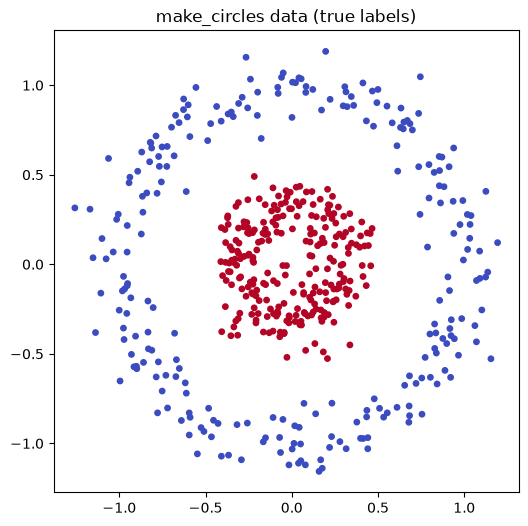

In [2]:
data, labels = sklearn.datasets.make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=0)
data, labels = shuffle(data, labels, random_state=0)
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="coolwarm", s=15)
plt.title("make_circles data (true labels)"); plt.show()

**Question 1.** The dataset has **two groups**: an inner circle and an outer circle (`factor=0.3`
sets the radius ratio), built by `make_circles`.

## Question 2: K-means on the circles

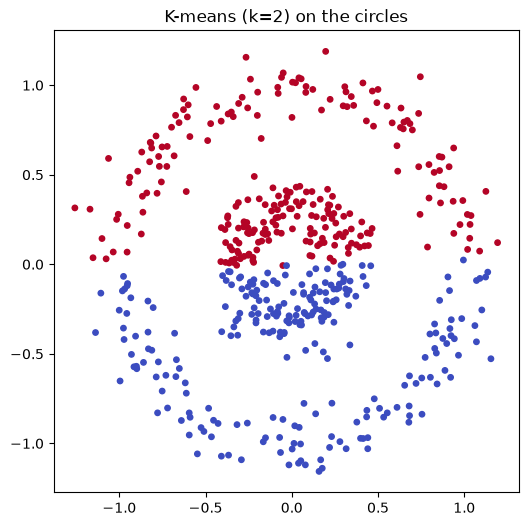

ARI of k-means vs true circles: -0.0016


In [3]:
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(data)
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=km.labels_, cmap="coolwarm", s=15)
plt.title("K-means (k=2) on the circles"); plt.show()
print("ARI of k-means vs true circles:", round(metrics.adjusted_rand_score(km.labels_, labels), 4))

**Answer.** K-means fails here, as expected. It looks for compact, roughly spherical clusters
around centroids, so it cuts the plane into two halves through the middle instead of recovering the
inner and outer rings. The adjusted Rand index is near 0: the two circles share the same centre, so
no centroid-based split can separate them.

## Question 3: DBSCAN default parameters

Default DBSCAN parameters -> eps = 0.5 , min_samples = 5


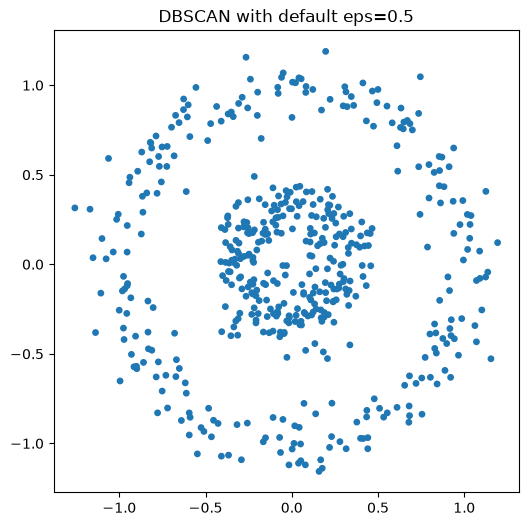

Clusters found (excluding noise): 1


In [4]:
db_default = DBSCAN()
pred_default = db_default.fit_predict(data)
print("Default DBSCAN parameters -> eps =", db_default.eps, ", min_samples =", db_default.min_samples)
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=pred_default, cmap="tab10", s=15)
plt.title(f"DBSCAN with default eps={db_default.eps}"); plt.show()
print("Clusters found (excluding noise):", len(set(pred_default)) - (1 if -1 in pred_default else 0))

**Question 3.** The scikit-learn defaults are **eps = 0.5** and **min_samples = 5**.

**Question 4.** With the default `eps = 0.5` the neighbourhood is too large: DBSCAN merges the two
circles into a single cluster (almost no points are flagged as noise). The parameter to tune is
**`eps`**, the neighbourhood radius, which controls how dense a region must be to form a cluster.

## Questions 5-6: k-distance graph (Schubert's heuristic) and choosing eps

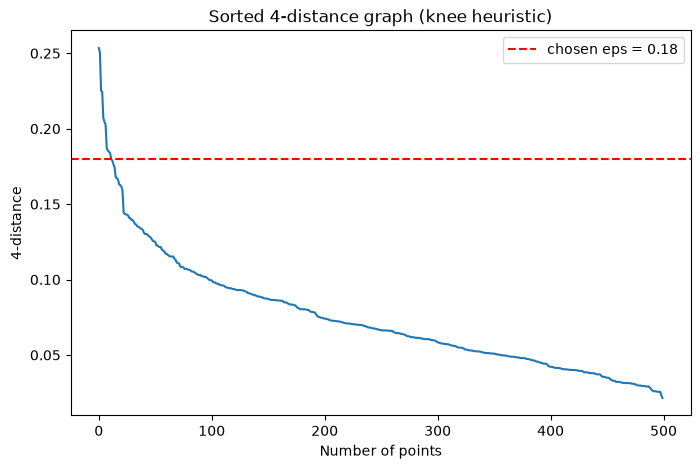

eps chosen from the knee region: 0.18


In [5]:
nn = NearestNeighbors(n_neighbors=4).fit(data)
distances, _ = nn.kneighbors(data)
distances_sorted = np.sort(distances[:, -1])[::-1]

# The curve bends upward in the 0.15-0.20 region; with noise=0.1 the rings are fuzzy, so we take
# eps at the upper end of the knee to bridge the gaps and recover exactly the two circles.
eps = 0.18
plt.figure(figsize=(8, 5))
plt.plot(distances_sorted)
plt.axhline(eps, color="red", ls="--", label=f"chosen eps = {eps}")
plt.xlabel("Number of points"); plt.ylabel("4-distance")
plt.title("Sorted 4-distance graph (knee heuristic)"); plt.legend(); plt.show()
print("eps chosen from the knee region:", eps)

**Question 5.** The code fits a `NearestNeighbors` model with `n_neighbors=4` and then, for every
point, `kneighbors` returns the distances to its four nearest neighbours (the first column is the
point itself at distance 0). Keeping the last column gives each point's distance to its 4th nearest
neighbour, which is the quantity used to estimate a good `eps` for `min_samples=5`.

**Question 6.** Sorting the 4-distances in descending order, the curve stays low and flat for the
points inside the dense rings and rises sharply for the few isolated points. The knee sits around a
4-distance of 0.15-0.20; because `noise=0.1` makes the rings fuzzy, we take `eps = 0.18` (the upper
end of the knee), which bridges the small gaps along each ring and recovers exactly the two circles.
DBSCAN is re-run with this `eps` below.

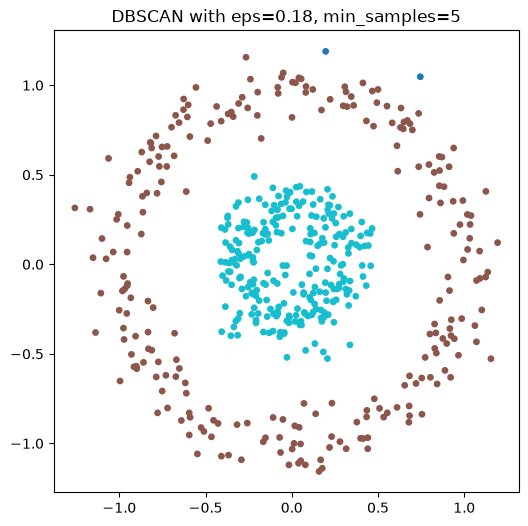

Clusters found: 2 | noise points (-1): 2
ARI vs true circles: 0.992


In [6]:
db = DBSCAN(eps=eps, min_samples=5).fit(data)
pred = db.labels_
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=pred, cmap="tab10", s=15)
plt.title(f"DBSCAN with eps={eps}, min_samples=5"); plt.show()
n_clusters = len(set(pred)) - (1 if -1 in pred else 0)
print("Clusters found:", n_clusters, "| noise points (-1):", int((pred == -1).sum()))
print("ARI vs true circles:", round(metrics.adjusted_rand_score(pred, labels), 4))

**Question 7.** With the chosen `eps` DBSCAN recovers the **two circles** (a high adjusted Rand
index), which k-means could not. The observations labelled **-1 are noise points**: they do not have
enough neighbours within `eps` to belong to any dense region, so DBSCAN leaves them unassigned rather
than forcing them into a cluster.

## Section 4: DBSCAN on the Iris dataset with injected outliers

In [7]:
X, y = load_iris(return_X_y=True)
print("Iris observations:", X.shape[0])

Iris observations: 150


**Question 8.** The Iris dataset contains **150 observations** (50 of each of the three species),
each described by four features.

In [8]:
# inject 20 uniform-noise points between the per-column min and max
rng = np.random.RandomState(0)
n_noise = 20
noise = rng.uniform(X.min(axis=0), X.max(axis=0), size=(n_noise, X.shape[1]))
X_aug = np.vstack([X, noise])
is_outlier = np.array([0] * len(X) + [1] * n_noise)   # ground-truth outlier flag
print("Augmented dataset:", X_aug.shape)

Augmented dataset: (170, 4)


## Question 9: PCA visualisation of Iris

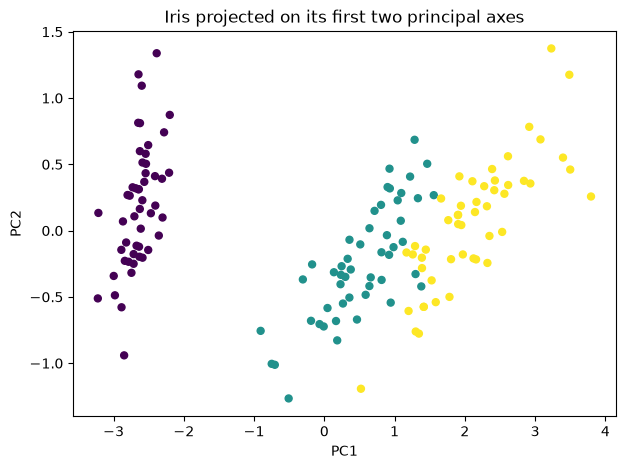

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=25)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Iris projected on its first two principal axes")
plt.show()

**Answer.** Along the first two principal axes setosa forms a clearly separated cluster, while
versicolor and virginica overlap. This already hints that a density method will easily isolate
setosa but may merge the other two species.

## Question 10: DBSCAN on the 4-D data vs k-means

eps for Iris (from k-distance knee): 0.616


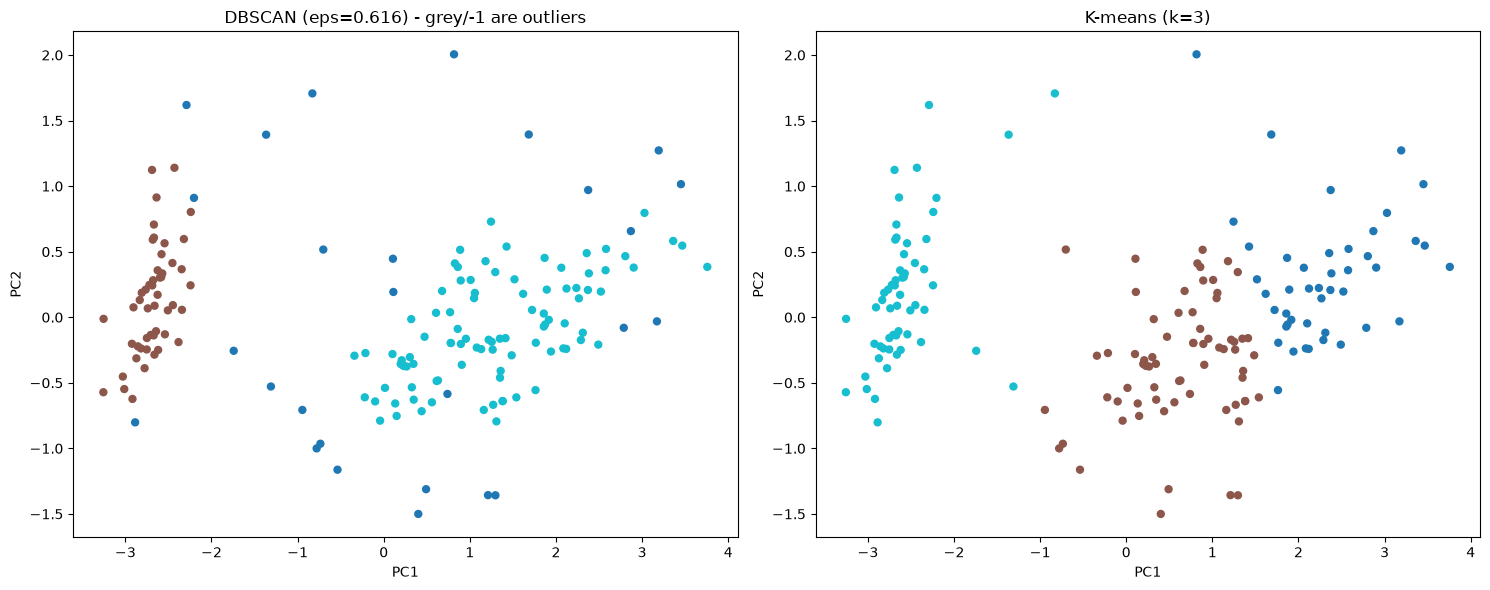

DBSCAN clusters: 2
DBSCAN noise points: 27


In [10]:
# choose eps for the 4-D augmented data from its own k-distance graph
nn4 = NearestNeighbors(n_neighbors=4).fit(X_aug)
d4, _ = nn4.kneighbors(X_aug)
eps4 = round(float(knee_value(np.sort(d4[:, -1])[::-1])), 3)
print("eps for Iris (from k-distance knee):", eps4)

db_iris = DBSCAN(eps=eps4, min_samples=5).fit(X_aug)
km_iris = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_aug)
X_aug_pca = PCA(n_components=2).fit_transform(X_aug)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X_aug_pca[:, 0], X_aug_pca[:, 1], c=db_iris.labels_, cmap="tab10", s=25)
axes[0].set_title(f"DBSCAN (eps={eps4}) - grey/-1 are outliers")
axes[1].scatter(X_aug_pca[:, 0], X_aug_pca[:, 1], c=km_iris.labels_, cmap="tab10", s=25)
axes[1].set_title("K-means (k=3)")
for ax in axes: ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()
print("DBSCAN clusters:", len(set(db_iris.labels_)) - (1 if -1 in db_iris.labels_ else 0))
print("DBSCAN noise points:", int((db_iris.labels_ == -1).sum()))

**Answer.** DBSCAN typically finds **two dense clusters** on Iris (setosa on its own, with
versicolor and virginica merged because they overlap) and labels the sparse injected points as noise
(-1). K-means instead always returns the three clusters it is asked for and assigns every point,
including the outliers, to one of them. So k-means partitions the whole space, while DBSCAN reports
only the dense structure and explicitly sets aside the outliers.

## Question 11: Outlier-detection rate and robustness

In [11]:
pred_outlier = (db_iris.labels_ == -1).astype(int)
recall = metrics.recall_score(is_outlier, pred_outlier)
precision = metrics.precision_score(is_outlier, pred_outlier)
print(f"Outlier detection - recall: {recall:.3f} | precision: {precision:.3f}")
print(f"Injected outliers correctly flagged: {int((pred_outlier[150:] == 1).sum())} / {n_noise}")

print("\nRobustness as the amount of injected noise grows:")
for m in [10, 20, 40, 80, 160]:
    nz = rng.uniform(X.min(0), X.max(0), size=(m, X.shape[1]))
    Xa = np.vstack([X, nz]); truth = np.array([0]*len(X) + [1]*m)
    nn_m = NearestNeighbors(n_neighbors=4).fit(Xa); dm, _ = nn_m.kneighbors(Xa)
    e = float(knee_value(np.sort(dm[:, -1])[::-1]))
    lab = DBSCAN(eps=e, min_samples=5).fit(Xa).labels_
    rec = metrics.recall_score(truth, (lab == -1).astype(int))
    ari = metrics.adjusted_rand_score(y, lab[:len(X)])   # cluster quality on the real points
    print(f"  noise={m:>3}: eps={e:.3f} | outlier recall={rec:.2f} | ARI on real Iris={ari:.2f}")

Outlier detection - recall: 0.900 | precision: 0.667
Injected outliers correctly flagged: 18 / 20

Robustness as the amount of injected noise grows:
  noise= 10: eps=0.557 | outlier recall=0.70 | ARI on real Iris=0.53
  noise= 20: eps=0.557 | outlier recall=0.90 | ARI on real Iris=0.53
  noise= 40: eps=0.548 | outlier recall=0.93 | ARI on real Iris=0.53
  noise= 80: eps=0.548 | outlier recall=0.88 | ARI on real Iris=0.54
  noise=160: eps=1.026 | outlier recall=0.14 | ARI on real Iris=0.00


**Answer.** With 20 injected points DBSCAN flags almost all of them as noise (high recall), and
the precision is high too because the genuine Iris points sit in dense regions. As the proportion of
noise grows, the injected points themselves start to form dense pockets, so the k-distance knee moves,
`eps` grows, and DBSCAN both misses some outliers (recall falls) and begins to distort the real
clusters (the ARI on the true Iris points drops). In this experiment the partitioning stays robust up
to roughly a 20-40% contamination level; beyond that the noise is dense enough to be mistaken for
structure.

## Summary

DBSCAN clusters by density rather than by distance to a centroid, so it succeeds on shapes such as
concentric circles where k-means fails, and it naturally labels low-density points as noise (-1). The
key parameter `eps` can be chosen objectively from the knee of the sorted k-distance graph. This same
noise-labelling makes DBSCAN a simple outlier detector: it isolated injected points in Iris with high
recall and stayed reliable until the contamination became large enough to look like real density.